In [57]:
%matplotlib inline

import torch
from torch.distributions import multinomial

In [58]:
fair_probs = torch.ones([6])/6
multinomial.Multinomial(1, fair_probs).sample()

tensor([0., 0., 0., 0., 1., 0.])

In [59]:
z = multinomial.Multinomial(100, fair_probs).sample()
z, z.sum()

(tensor([10., 21., 26., 18., 17.,  8.]), tensor(100.))

In [60]:
counts = multinomial.Multinomial(100000, fair_probs).sample()
counts / 100000, fair_probs

(tensor([0.1679, 0.1672, 0.1649, 0.1666, 0.1663, 0.1671]),
 tensor([0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.1667]))

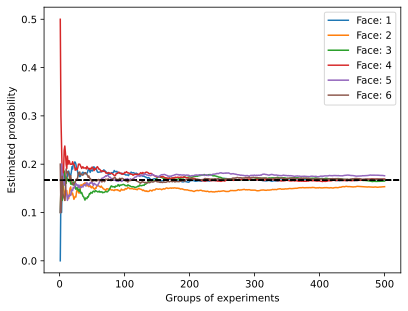

In [61]:
counts = multinomial.Multinomial(10, fair_probs).sample((500, ))
# print(counts, counts.shape)
cum_counts = counts.cumsum(dim = 0)
# print(cum_counts, cum_counts.shape)
estimate = cum_counts / cum_counts.sum(dim=1, keepdim=True)
# print(estimate)

from matplotlib_inline import backend_inline
import matplotlib.pyplot as plt

backend_inline.set_matplotlib_formats('svg')

fig, ax = plt.subplots()
ax.set_xlabel("Groups of experiments")
ax.set_ylabel("Estimated probability")

for i in range(6):
    ax.plot([i for i in range(1, 501)],estimate[:, i].numpy(), label=f"Face: {i + 1}")
    ax.axhline(y=0.167, linestyle='dashed', color='black')

ax.legend()
plt.show()
    